Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    10 non-null     int64  
 1   V1      10 non-null     float64
 2   V2      10 non-null     float64
 3   V3      10 non-null     float64
 4   V4      10 non-null     float64
 5   V5      10 non-null     float64
 6   Amount  10 non-null     float64
 7   Class   10 non-null     int64  
dtypes: float64(6), int64(2)
memory usage: 772.0 bytes

First few rows of the dataset:
   Time        V1        V2        V3        V4        V5  Amount  Class
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  149.62      0
1     1  1.191857  0.266151  0.166480  0.448154  0.060018    2.69      0
2     2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  378.66      0
3     3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  123.50      0
4     4 -1.158233  0.877737  1.548718  0.403034 -0.407193   69.

C:\Users\ilango\AppData\Local\Temp\ipykernel_15860\1287375676.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df, palette='PuBu')


NameError: name 'StratifiedKFold' is not defined

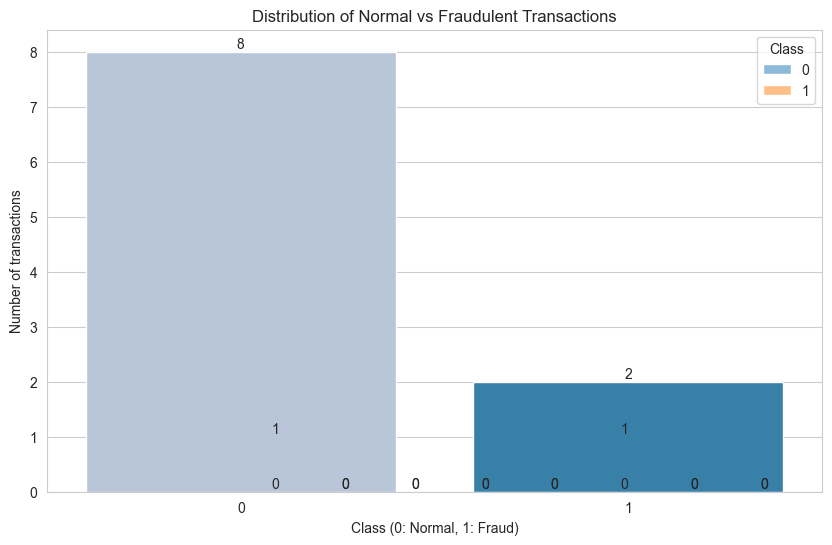

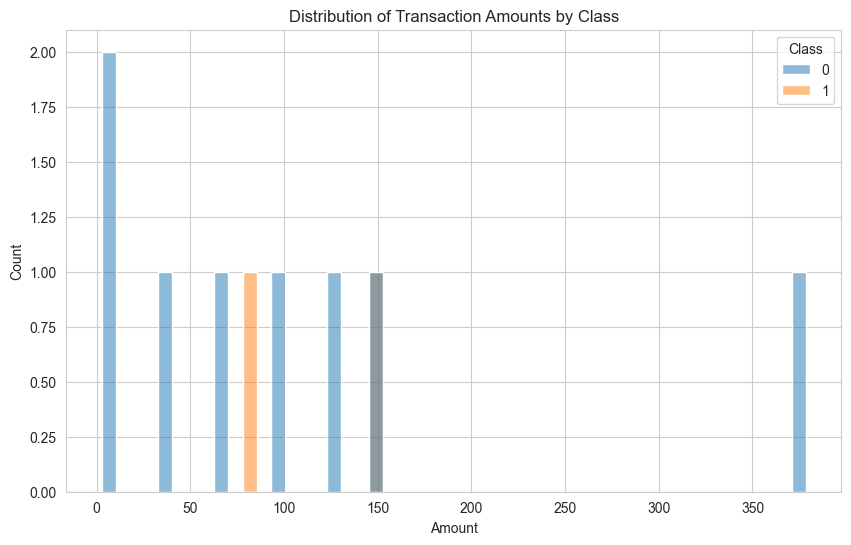

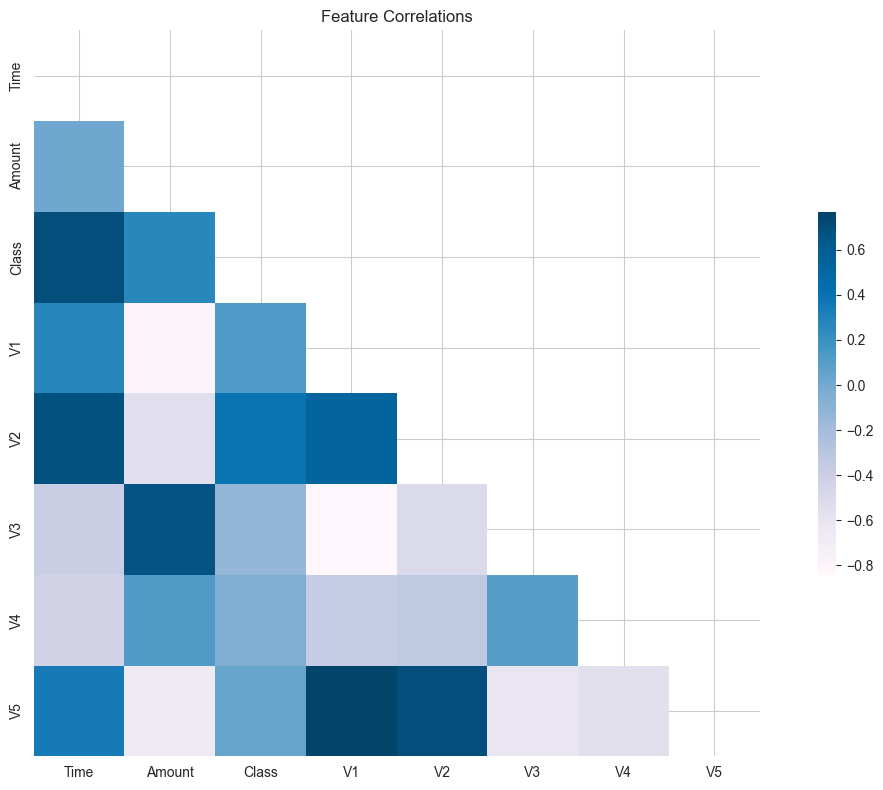

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import random
import tensorflow as tf
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

# Configure plotting
plt.style.use('default')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Function to send email notification
def send_email_notification(to_email, subject, message):
    # Email account credentials
    sender_email = os.getenv("EMAIL")
    sender_password = os.getenv("PASSWORD")

    # Create the email
    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = to_email
    msg['Subject'] = subject

    # Attach the message content
    msg.attach(MIMEText(message, 'plain'))

    try:
        # Connect to the SMTP server
        with smtplib.SMTP('smtp.gmail.com', 587) as server:  # Replace with your SMTP server if not using Gmail
            server.starttls()  # Secure the connection
            server.login(sender_email, sender_password)
            server.send_message(msg)
            print("Email sent successfully to", to_email)
    except Exception as e:
        print("Failed to send email:", e)

# Load the sample creditcard dataset
df = pd.read_csv('sample_creditcard.csv')

# Print dataset info
print("Dataset Info:")
df.info()

# Show first few rows
print("\nFirst few rows of the dataset:")
print(df.head())

# Sample data
df.sample(5)

# Check for null values
df.isnull().sum()

# Get basic statistics for Amount and Time
print("Transaction Amount Statistics:")
print(df['Amount'].describe())
print("\nTransaction Time Statistics:")
print(df['Time'].describe())

# Optimize memory usage by downcasting numerical columns
for col in df.columns:
    if df[col].dtype == 'float64':
        df[col] = pd.to_numeric(df[col], downcast='float')
    elif df[col].dtype == 'int64':
        df[col] = pd.to_numeric(df[col], downcast='integer')

# Check duplicate values
df.duplicated().sum()

# Analyze time distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Time', hue='Class', bins=50)
plt.title('Distribution of Transactions over Time by Class')
plt.xlabel('Time (seconds)')
plt.ylabel('Count')

# Plot class distribution
ax = sns.countplot(x='Class', data=df, palette='PuBu')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribution of Normal vs Fraudulent Transactions')
plt.ylabel('Number of transactions')
plt.xlabel('Class (0: Normal, 1: Fraud)')

# Plot amount distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Amount', hue='Class', bins=50)
plt.title('Distribution of Transaction Amounts by Class')
plt.xlabel('Amount')
plt.ylabel('Count')

# Calculate correlation matrix
# Adjust the columns to match the dataset
cols_to_correlate = ['Time', 'Amount', 'Class'] + [f'V{i}' for i in range(1, 29) if f'V{i}' in df.columns]
corr_matrix = df[cols_to_correlate].corr('spearman')

# Create correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='PuBu', center=0,
            mask=np.triu(np.ones_like(corr_matrix, dtype=bool)),
            fmt='.2f', square=True, cbar_kws={'shrink': .5})
plt.title('Feature Correlations')
plt.tight_layout()

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Scale Amount and Time features
scaler = StandardScaler()
df[['Amount', 'Time']] = scaler.fit_transform(df[['Amount', 'Time']])

# Check duplicate values
df.duplicated().sum()

# Stratified train-test split
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
for train_idx, test_idx in skfold.split(X,y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

sc = StandardScaler()
scaled_train = sc.fit_transform(X_train)
scaled_test = sc.transform(X_test)
X_train = pd.DataFrame(scaled_train, index=X_train.index, columns=X_train.columns)
X_test = pd.DataFrame(scaled_test, index=X_test.index, columns=X_test.columns)

X_train, y_train = RandomUnderSampler(sampling_strategy='majority').fit_resample(X_train, y_train)

# Model comparison function
def model_comparison_evaluate(classifiers, X, y):
    print('K-Fold Cross-Validation:\n')
    for name, model in classifiers.items():
        print('{}:'.format(name))
        
        scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
        
        for score in scoring:
            scores = cross_val_score(model, X, y, scoring=score, cv=skfold, n_jobs=-1)
            print('Mean {} score: {:.3f} ({:.3f})'.format(score, scores.mean(), scores.std()))
            
        print('\n')

# Example usage
# Use environment variables for recipient email, subject, and message
recipient_email = os.getenv("RECIPIENT_EMAIL", "recipient@example.com")
email_subject = os.getenv("EMAIL_SUBJECT", "Test Email")
email_message = os.getenv("EMAIL_MESSAGE", "This is a test email to verify the implementation.")

send_email_notification(recipient_email, email_subject, email_message)

seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

X = df.copy()
X.drop(['Class'], axis=1, inplace=True)  # 'Class' is our target variable
y = df['Class']  # 1 for fraud, 0 for normal

# Stratified train-test split
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
for train_idx, test_idx in skfold.split(X,y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

sc = StandardScaler()
scaled_train = sc.fit_transform(X_train)
scaled_test = sc.transform(X_test)
X_train = pd.DataFrame(scaled_train, index=X_train.index, columns=X_train.columns)
X_test = pd.DataFrame(scaled_test, index=X_test.index, columns=X_test.columns)

X_train, y_train = RandomUnderSampler(sampling_strategy='majority').fit_resample(X_train, y_train)

classifiers = { 'Random Forest Classifier':RandomForestClassifier(class_weight='balanced', random_state=seed),
                'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=seed)
              }
model_comparison_evaluate(classifiers, X_train, y_train)

model = RandomForestClassifier(class_weight='balanced', random_state=seed)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_score = model.predict_proba(X_test)[:,1]
print('Random Forest Classifier:')
print(classification_report(y_pred, y_test, labels=[0,1], target_names=['Non-Fraud [0]', 'Fraud [1]']), '\n')

fig, ax = plt.subplots(1, 2, figsize=(20,5))
ax[0].set_title('Confusion Matrix of Random Forest Model:')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False, values_format='', cmap='crest', ax=ax[0])
ax[0].grid(False)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_score)
roc_auc = auc(fpr, tpr)                       
ax[1].set_title('ROC Curve - Random Forest Classifier')
ax[1].plot(fpr, tpr, label = 'AUC = %0.3f' % roc_auc, c='steelblue')
ax[1].plot([0,1],[0,1],'--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')